# Exploratory Data Analysis

In [1]:
import sys

# Necessary to import from src dir
sys.path.append('..')

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re
import seaborn as sns

from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from src.kmeans import get_contingency_table_for_clustering_results, inverse_probability_weighting, run_k_means_for_range
from src.pca import biplot, get_features_by_importance, plot_explained_variance
from src.preprocessing import prepare_standardized_datasets

In [17]:
DATA_DIR = r"./data/"
OUTPUT_DIR = r"./outputs/"

TRAIN_DATA = os.path.join(DATA_DIR, "train.csv")
TEST_DATA = os.path.join(DATA_DIR, "test.csv")

# Preprocessing

df_train = pd.read_csv(TRAIN_DATA)
df_test = pd.read_csv(TEST_DATA)

label_var = "class4"

# Include only the real-valued mean values, but don't exclude anything further than that yet before exploring the data a bit first
cols_to_include = [feat for feat in df_train.columns.to_list() if (feat.endswith(".mean")) or (feat == label_var)]

numeric_vars = cols_to_include[:]
numeric_vars.remove(label_var)

df_train_standardized, _, df_test_standardized = prepare_standardized_datasets(
    df_train=df_train,
    df_test=df_test,
    data_vars=numeric_vars,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=False
)

df_train_standardized.head()

,class4,class2,CO2168.mean,CO2336.mean,CO242.mean,CO2504.mean,Glob.mean,H2O168.mean,H2O336.mean,H2O42.mean,...,SO2168.mean,SWS.mean,T168.mean,T42.mean,T504.mean,T672.mean,T84.mean,UV_A.mean,UV_B.mean,CS.mean
0,II,event,-0.867780,-0.883382,-0.929523,-0.878777,-0.513499,-0.783647,-0.779782,-0.781824,...,-0.456136,0.541758,-0.299145,-0.282750,-0.305683,-0.324836,-0.287664,-0.688861,-1.030310,-1.147189
1,nonevent,nonev,-0.823577,-0.839333,-0.882343,-0.833255,0.189801,-0.755609,-0.749101,-0.762649,...,-0.373313,0.466385,-0.702567,-0.679542,-0.713507,-0.736281,-0.688947,0.125321,-0.442983,-1.059902
2,Ia,event,-0.735765,-0.747661,-0.793051,-0.741507,1.233848,-0.837948,-0.834977,-0.833538,...,-0.271270,0.516825,-0.353630,-0.326983,-0.371040,-0.391842,-0.331950,0.890057,0.374255,-0.995347
3,Ib,event,-0.544192,-0.558780,-0.569606,-0.555771,1.371208,-0.746872,-0.739906,-0.742423,...,0.942006,0.535711,-0.202552,-0.191413,-0.222589,-0.245364,-0.179461,1.006066,0.862974,-0.445754
4,nonevent,nonev,-0.717947,-0.724841,-0.759015,-0.713551,-1.053162,-0.004673,-0.005885,-0.017888,...,-0.276519,-2.273178,-0.455287,-0.448823,-0.443364,-0.459731,-0.451326,-0.984617,-0.932361,-0.193122


## General view at the data

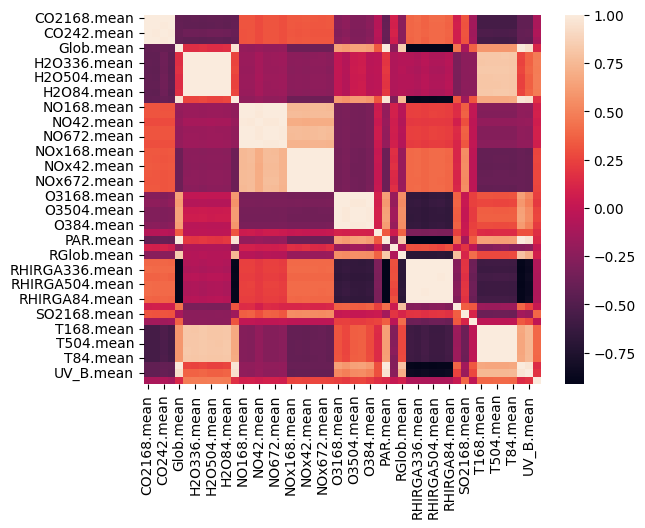

In [18]:
# Correlations between numeric variables

corr = df_train_standardized.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

## PCA

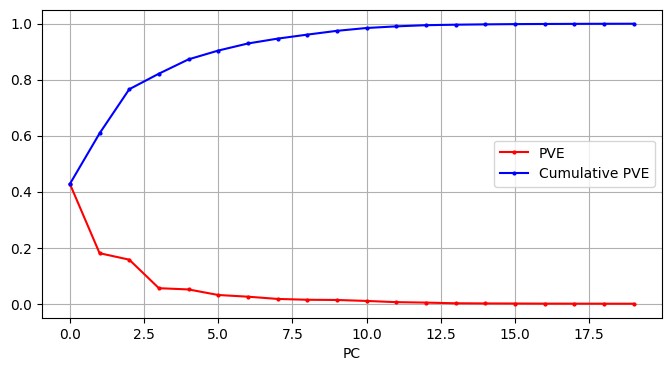

In [4]:
X_train = df_train_standardized[numeric_vars]
y_train = df_train_standardized[[label_var]]

pca = PCA(n_components=20)
pca_results = pca.fit(X_train)
scores = pca.transform(X_train)

fig, ax = plt.subplots(figsize=(8, 4))
plot_explained_variance(pca_results.explained_variance_ratio_, ax)

### PC1 & PC2

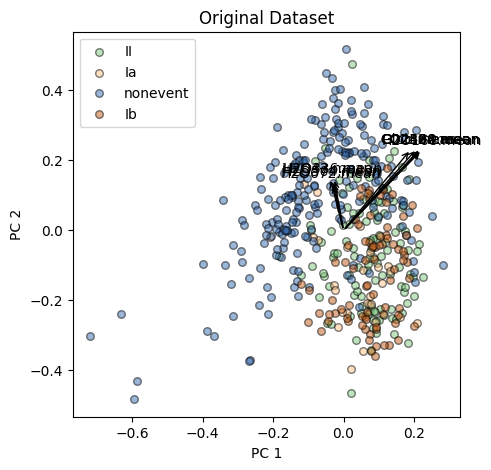

In [5]:
# Plot data projected to PC1 & PC2

fig, ax = plt.subplots(figsize=(5, 5))
top_features = biplot(scores, y_train, ax, title='Original Dataset', pca_result=pca_results, variables=X_train.columns.to_list(), include_arrows=True, n_arrow_variables=10)

In [9]:
# Features that most impact these components
top_features

['H2O672.mean',
 'H2O504.mean',
 'H2O336.mean',
 'H2O168.mean',
 'H2O84.mean',
 'H2O42.mean',
 'RHIRGA42.mean',
 'RHIRGA84.mean',
 'RHIRGA168.mean',
 'RHIRGA336.mean']

In [8]:
# Can also use the function get_features_by_importance()
get_features_by_importance(X_train.columns.to_list(), pca_results, 0, 1, n_features=5)

['H2O672.mean', 'H2O504.mean', 'H2O336.mean', 'H2O168.mean', 'H2O84.mean']

In [14]:
# Look at the significant features for combinations of the first 5 principal components
pc5_combos = list(combinations([1,2,3,4,5], 2))

all_major_features = []

for combo in pc5_combos:
    major_features = get_features_by_importance(X_train.columns.to_list(), pca_results, combo[0], combo[1], n_features=10)
    print(major_features)
    all_major_features = all_major_features + major_features

all_major_features = list(set(all_major_features))

['H2O504.mean', 'H2O672.mean', 'H2O336.mean', 'H2O168.mean', 'H2O84.mean', 'H2O42.mean', 'NO504.mean', 'NO672.mean', 'NO336.mean', 'NO168.mean']
['CS.mean', 'O342.mean', 'O384.mean', 'O3168.mean', 'O3504.mean', 'O3672.mean', 'SO2168.mean', 'H2O672.mean', 'H2O504.mean', 'H2O336.mean']
['CO242.mean', 'CO2336.mean', 'CO2504.mean', 'CO2168.mean', 'H2O672.mean', 'H2O504.mean', 'H2O336.mean', 'H2O168.mean', 'H2O84.mean', 'H2O42.mean']
['Pamb0.mean', 'RPAR.mean', 'RGlob.mean', 'SO2168.mean', 'PTG.mean', 'SWS.mean', 'O342.mean', 'O384.mean', 'H2O672.mean', 'H2O504.mean']
['CS.mean', 'O3672.mean', 'O3504.mean', 'O342.mean', 'O3168.mean', 'O384.mean', 'NO42.mean', 'SO2168.mean', 'NO84.mean', 'NO672.mean']
['CO242.mean', 'CO2336.mean', 'CO2504.mean', 'CO2168.mean', 'NO42.mean', 'NO672.mean', 'NO504.mean', 'NO336.mean', 'NO168.mean', 'NO84.mean']
['Pamb0.mean', 'NO42.mean', 'NO84.mean', 'NO672.mean', 'NO168.mean', 'NO504.mean', 'NO336.mean', 'SO2168.mean', 'PTG.mean', 'RPAR.mean']
['CO242.mean', '

In [13]:
len(all_major_features)

28

## Combine variables

Combine variables that have been measured at multiple mast heights.

In [19]:
patterns = {
    "CO2_combined.mean": rf"CO2\d{{2,3}}.mean",
    "H2O_combined.mean": rf"H2O\d{{2,3}}.mean",
    "NO_combined.mean": rf"NO\d{{2,3}}.mean",
    "NOx_combined.mean": rf"NOx\d{{2,3}}.mean",
    "O3_combined.mean": rf"O3\d{{2,3}}.mean",
    "RHIRGA_combined.mean": rf"RHIRGA\d{{2,3}}.mean",
    "T_combined.mean": rf"T\d{{2,3}}.mean"
}

for col, pattern in patterns.items():
    cols_to_combine = []
    for feat in df_train_standardized.columns.to_list():
        matches = re.findall(pattern, feat)
        if len(matches) > 0:
            cols_to_combine = cols_to_combine + matches

    if len(combo) > 1:
        df_train_standardized[col] = df_train_standardized[cols_to_combine].mean(axis=1)

        df_train_standardized = df_train_standardized.drop(columns=cols_to_combine)

df_train_standardized.head()

,class4,class2,Glob.mean,NET.mean,Pamb0.mean,PAR.mean,PTG.mean,RGlob.mean,RPAR.mean,SO2168.mean,...,UV_A.mean,UV_B.mean,CS.mean,CO2_combined.mean,H2O_combined.mean,NO_combined.mean,NOx_combined.mean,O3_combined.mean,RHIRGA_combined.mean,T_combined.mean
0,II,event,-0.513499,0.322454,-0.199772,-0.569240,-0.574575,0.973922,1.073593,-0.456136,...,-0.688861,-1.030310,-1.147189,-0.889865,-0.780436,-0.178952,-0.284600,1.388916,-0.786166,-0.300016
1,nonevent,nonev,0.189801,0.074992,-1.073879,0.173800,-0.621839,0.454001,0.610175,-0.373313,...,0.125321,-0.442983,-1.059902,-0.844627,-0.753020,-0.155105,-0.271621,0.909264,0.129127,-0.704169
2,Ia,event,1.233848,0.714300,0.964481,1.161737,-0.787961,1.345042,1.360285,-0.271270,...,0.890057,0.374255,-0.995347,-0.754496,-0.834990,-0.231659,-0.348816,1.396415,-0.803580,-0.355089
3,Ib,event,1.371208,1.154409,0.955663,1.306693,-0.909832,1.554699,1.473010,0.942006,...,1.006066,0.862974,-0.445754,-0.557087,-0.741356,-0.159498,-0.089672,1.387521,-0.853273,-0.208276
4,nonevent,nonev,-1.053162,-0.912734,-1.574642,-1.039388,-0.062324,-1.013612,-0.609127,-0.276519,...,-0.984617,-0.932361,-0.193122,-0.728839,-0.004625,-0.117630,0.546963,0.658148,1.501463,-0.451706


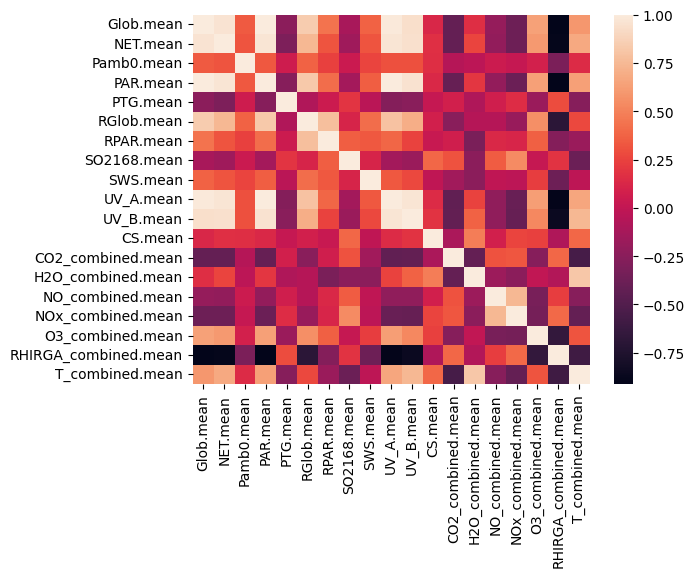

In [20]:
# Correlations for reduced data

corr = df_train_standardized.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

In [25]:
# Based on data description and the correlation matrix, could probably also combine (in some manner):
# - Glob.mean, RGlob.mean, perhaps even NET.mean
# - PAR.mean, RPAR.mean
# - UV_A.mean, UV_B.mean

## PCA on reduced data

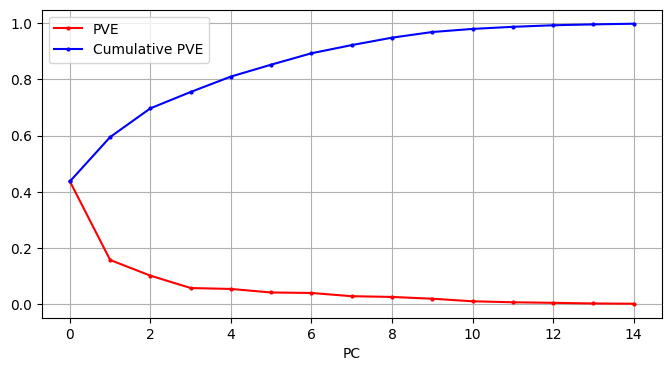

In [22]:
numeric_vars_updated = [feat for feat in df_train_standardized.columns.to_list() if (feat.endswith(".mean"))]

X_train = df_train_standardized[numeric_vars_updated]
y_train = df_train_standardized[[label_var]]

pca = PCA(n_components=15)
pca_results = pca.fit(X_train)
X_train_pca = pca.transform(X_train)

fig, ax = plt.subplots(figsize=(8, 4))
plot_explained_variance(pca_results.explained_variance_ratio_, ax)

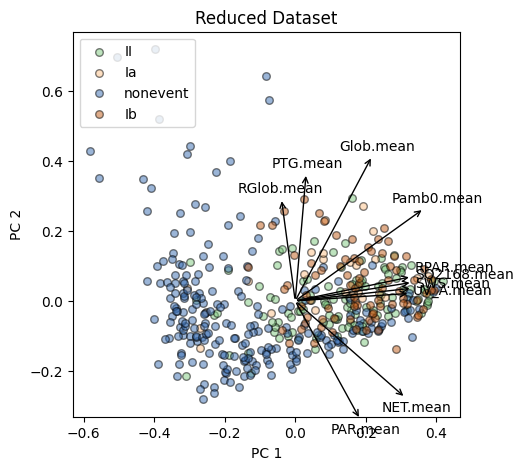

In [26]:
fig, ax = plt.subplots(figsize=(5, 5))
top_features = biplot(X_train_pca, y_train, ax, title='Reduced Dataset', pca_result=pca_results, variables=X_train.columns.to_list(), include_arrows=True, n_arrow_variables=10)

In [24]:
top_features

['RPAR.mean',
 'T_combined.mean',
 'RGlob.mean',
 'H2O_combined.mean',
 'SO2168.mean',
 'NOx_combined.mean',
 'Glob.mean',
 'PAR.mean',
 'UV_A.mean',
 'NET.mean']

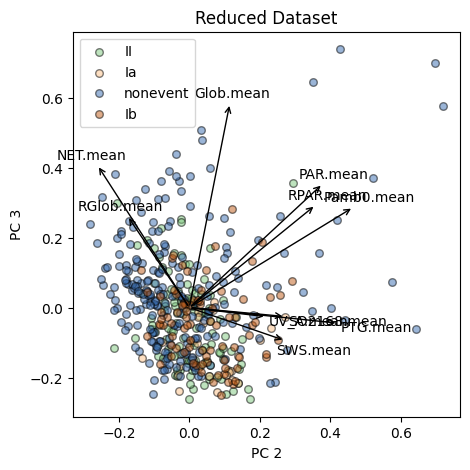

In [28]:
# Check out some other PC combinations

fig, ax = plt.subplots(figsize=(5, 5))
top_features = biplot(X_train_pca, y_train, ax, title='Reduced Dataset', pca_components_by_idx=[1, 2], pca_result=pca_results, variables=X_train.columns.to_list(), include_arrows=True, n_arrow_variables=10)

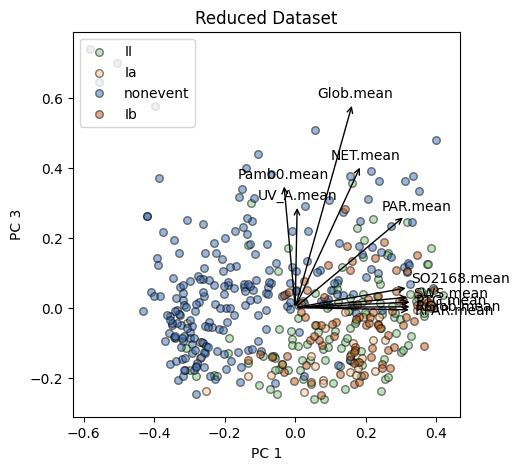

In [30]:
# Check out some other PC combinations

fig, ax = plt.subplots(figsize=(5, 5))
top_features = biplot(X_train_pca, y_train, ax, title='Reduced Dataset', pca_components_by_idx=[0, 2], pca_result=pca_results, variables=X_train.columns.to_list(), include_arrows=True, n_arrow_variables=10)

In [32]:
# Numeric encoding for classes to be able to visualize better

df_train_standardized["class4_numeric"] = 0
df_train_standardized.loc[(df_train_standardized["class4"] == "Ia"), "class4_numeric"] = 1
df_train_standardized.loc[(df_train_standardized["class4"] == "Ib"), "class4_numeric"] = 2
df_train_standardized.loc[(df_train_standardized["class4"] == "II"), "class4_numeric"] = 3

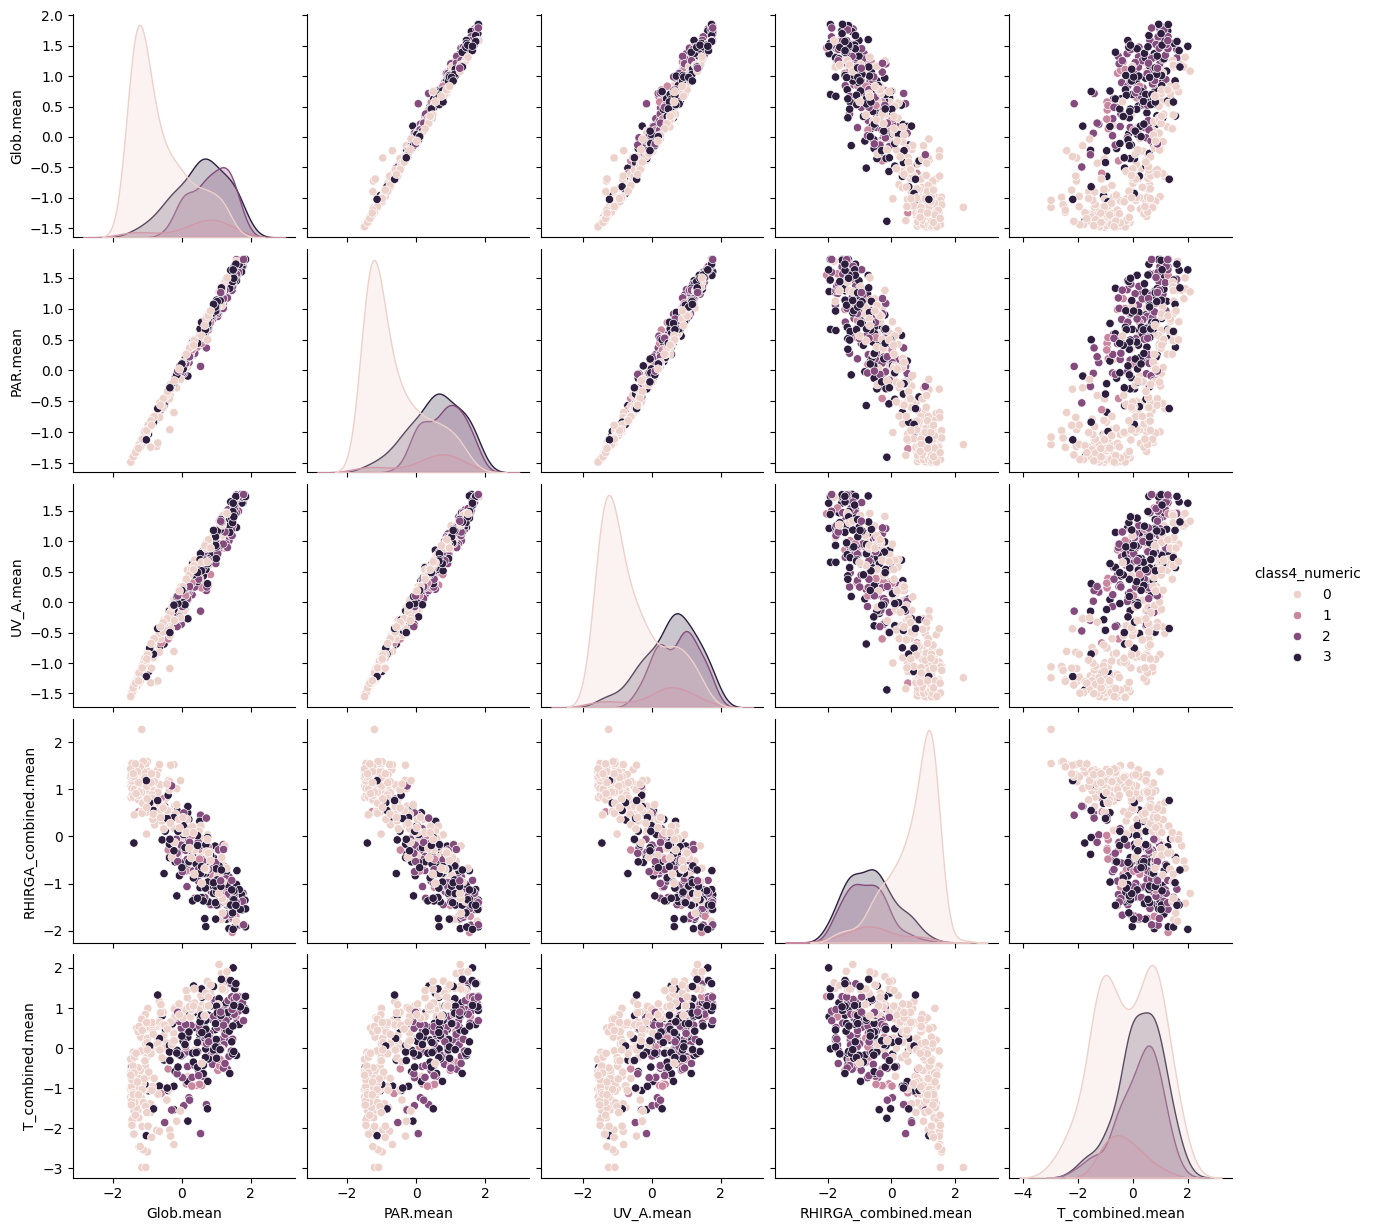

In [33]:
interesting_variables = ['Glob.mean', 'PAR.mean', 'UV_A.mean', 'RHIRGA_combined.mean', 'T_combined.mean']

sns.pairplot(df_train_standardized[['Glob.mean', 'PAR.mean', 'UV_A.mean', 'RHIRGA_combined.mean', 'T_combined.mean', 'class4_numeric']], hue='class4_numeric')

## Strongest events vs. nonevents

Events of type Ia are ones with highest confidence. Event type II contains events where accuracy of the results is questionable. Event type II could perhaps be dropped initially, to draw clearer distinction between events and nonevents. Let's study the impact of that.

In [34]:
# Reset variables

numeric_vars = cols_to_include[:]
numeric_vars.remove(label_var)

df_train_standardized, _, df_test_standardized = prepare_standardized_datasets(
    df_train=df_train,
    df_test=df_test,
    data_vars=numeric_vars,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=False
)

## K-means

K-means first with the basic setup (same as in exercises, and then with dropped Type II)

In [36]:
clustering_results, n_clusters = run_k_means_for_range(
    df_train_standardized,
    numeric_vars,
    n_min=4,
    n_max=4,
    n_init=200,
    init="k-means++"
)

clustering_result = clustering_results[0]
n_clusters = n_clusters[0]

df_train_standardized["cluster"] = clustering_result.labels_

contingency_table = get_contingency_table_for_clustering_results(df_train_standardized["class4"], df_train_standardized["cluster"])

contingency_table

cluster,2,1,0,3
class4,,,,
II,32,0,72,13
Ia,1,0,20,5
Ib,15,0,63,4
nonevent,100,4,14,107


In [37]:
# Drop event type II events
df_train_standardized = df_train_standardized.drop(df_train_standardized[df_train_standardized["class4"] == "II"].index)

In [38]:
# Re-do clustering with 3 clusters

clustering_results, n_clusters = run_k_means_for_range(
    df_train_standardized,
    numeric_vars,
    n_min=3,
    n_max=3,
    n_init=200,
    init="k-means++"
)

clustering_result = clustering_results[0]
n_clusters = n_clusters[0]

df_train_standardized["cluster"] = clustering_result.labels_

contingency_table = get_contingency_table_for_clustering_results(df_train_standardized["class4"], df_train_standardized["cluster"])

contingency_table

cluster,0,1,2
class4,,,
Ia,0,20,6
Ib,0,75,7
nonevent,4,104,117


In [44]:
# Try with weighting

class_weights = inverse_probability_weighting(df_train_standardized["class4"])
weighted_kmeans_result = KMeans(n_clusters=3, init="k-means++", n_init=200, random_state=666, algorithm="lloyd").fit(df_train_standardized[numeric_vars], sample_weight=class_weights)

weighted_contingency_table = get_contingency_table_for_clustering_results(df_train_standardized["class4"], weighted_kmeans_result.labels_)

weighted_contingency_table

col_0,1,2,0
class4,,,
Ia,20,1,5
Ib,48,31,3
nonevent,9,100,116


In [45]:
# Clearly K-means cannot separate between classes Ia and Ib, which is understandable, since they're both higher confidence events

# Try with binary classes – note! Classes are nonevents vs. type I events

clustering_results, n_clusters = run_k_means_for_range(
    df_train_standardized,
    numeric_vars,
    n_min=2,
    n_max=2,
    n_init=200,
    init="k-means++"
)

clustering_result = clustering_results[0]
n_clusters = n_clusters[0]

df_train_standardized["cluster"] = clustering_result.labels_

contingency_table = get_contingency_table_for_clustering_results(df_train_standardized["class2"], df_train_standardized["cluster"])

contingency_table

cluster,1,0
class2,,
event,96,12
nonev,112,113


In [46]:
# Try again with weighting (2 clusters)

class_weights = inverse_probability_weighting(df_train_standardized["class4"])
weighted_kmeans_result = KMeans(n_clusters=2, init="k-means++", n_init=200, random_state=666, algorithm="lloyd").fit(df_train_standardized[numeric_vars], sample_weight=class_weights)

weighted_contingency_table = get_contingency_table_for_clustering_results(df_train_standardized["class2"], weighted_kmeans_result.labels_)

weighted_contingency_table

col_0,0,1
class2,,
event,99,9
nonev,67,158
